In [1]:
#The import could time several minutes
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy import stats

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#Specific for this model
from sklearn.neighbors import KNeighborsClassifier
from dataclasses import dataclass,field
import bisect

In [2]:
df = pd.read_csv("../data/Customer-Churn-Records.csv",sep=",")
##Remove unecesary data
df=df.drop(columns=["RowNumber","CustomerId","Surname"])
##During first training was observed a so high correlation between Complain and Exited
df=df.drop(columns=["Complain"])
df.tail()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,1,DIAMOND,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,5,PLATINUM,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,3,SILVER,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2,GOLD,339
9999,792,France,Female,28,4,130142.79,1,1,0,38190.78,0,3,DIAMOND,911


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  str    
 2   Gender              10000 non-null  str    
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  Satisfaction Score  10000 non-null  int64  
 12  Card Type           10000 non-null  str    
 13  Point Earned        10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
df["Card Type"].unique()

<StringArray>
['DIAMOND', 'GOLD', 'SILVER', 'PLATINUM']
Length: 4, dtype: str

In [5]:
def change_card_type(cardType):
    catalog={
        "DIAMOND":3,
        "PLATINUM":2,
        "GOLD":1,
        "SILVER":0
    }
    return catalog[cardType]
df["Card Type"] = df["Card Type"].apply(change_card_type)

In [6]:
print(df.keys())

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='str')


In [7]:
df["Exited"].value_counts(normalize=True)
#is an unbalanced dataset

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

In [8]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,3.013800,1.501300,606.515100
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,1.405919,1.118357,225.924839
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,1.000000,0.000000,119.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,2.000000,1.000000,410.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,3.000000,2.000000,605.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,4.000000,3.000000,801.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,5.000000,3.000000,1000.000000


In [9]:
#Search outliers
print("key -> n_outliers")
for key in df.keys():
    try: 
        Q1 = df[key].quantile(0.25)
        Q3 = df[key].quantile(0.75)
        
        IQR = Q3 - Q1
        
        inferior = Q1 - 1.5 * IQR
        superior = Q3 + 1.5 * IQR
        
        outliers = df[(df[key] < inferior) | (df[key] > superior)]
        if (len(outliers) !=0):
            print(f"{key} -> {len(outliers)}")
    except:
        pass


key -> n_outliers
CreditScore -> 15
Age -> 359
NumOfProducts -> 60
Exited -> 2038


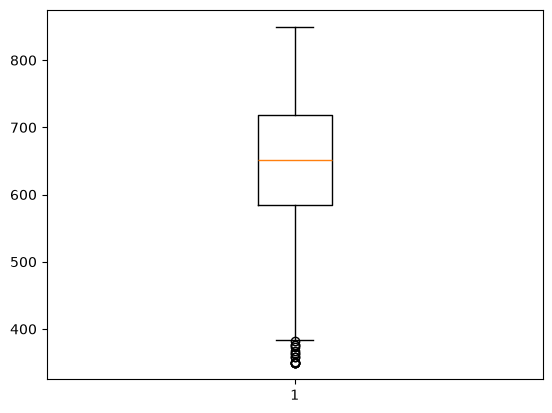

In [10]:
plt.boxplot(df["CreditScore"])
plt.show()

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  str    
 2   Gender              10000 non-null  str    
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  Satisfaction Score  10000 non-null  int64  
 12  Card Type           10000 non-null  int64  
 13  Point Earned        10000 non-null  int64  
dtypes: float64(2), int64(10), str(2)
memory usage: 1.1 MB


In [12]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,3.013800,1.501300,606.515100
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,1.405919,1.118357,225.924839
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,1.000000,0.000000,119.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,2.000000,1.000000,410.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,3.000000,2.000000,605.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,4.000000,3.000000,801.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,5.000000,3.000000,1000.000000


In [13]:
#Split data and to predict data
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)


In [15]:
scaler = RobustScaler()
ct = ColumnTransformer(
    transformers=[
        ('pass', 'passthrough', [ "HasCrCard", "IsActiveMember"]),
        ('encode', OneHotEncoder(drop="first",handle_unknown="ignore"), ['Geography',"Gender"])
    ],
    remainder=RobustScaler() # Keeps any columns not specified
)
ct.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pass', ...), ('encode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",RobustScaler()
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

In [16]:
X_test= ct.transform(X_test)
X_train=ct.transform(X_train)
print(ct.get_feature_names_out())


['pass__HasCrCard' 'pass__IsActiveMember' 'encode__Geography_Germany'
 'encode__Geography_Spain' 'encode__Gender_Male' 'remainder__CreditScore'
 'remainder__Age' 'remainder__Tenure' 'remainder__Balance'
 'remainder__NumOfProducts' 'remainder__EstimatedSalary'
 'remainder__Satisfaction Score' 'remainder__Card Type'
 'remainder__Point Earned']


In [17]:
description = stats.describe(X_train, axis=0)
print("Means per column:", description.mean)
print("Variances per column:", description.variance)

Means per column: [ 0.703125    0.513625    0.2495      0.249875    0.546125   -0.00590038
  0.158625    0.00725    -0.16252901  0.532      -0.00245911  0.0078125
  0.2470625   0.00702296]
Variances per column: [0.20876633 0.24984559 0.18727316 0.18746092 0.24790347 0.52533302
 0.7701375  0.33256901 0.2399019  0.34026853 0.34290422 0.49765742
 0.3122179  0.33233397]


In [18]:
print(X_train.shape)
print(y_train.shape)

#Verify that there aren't anomalies
print(np.max(X_train), np.min(X_train))



(8000, 14)
(8000,)
4.583333333333333 -2.263157894736842


In [19]:
for i in range(X_train.shape[1]):
    col_max = np.max(X_train[:, i])
    col_min = np.min(X_train[:, i])
    
    print(ct.get_feature_names_out()[i], "min:", col_min, "max:", col_max)

pass__HasCrCard min: 0.0 max: 1.0
pass__IsActiveMember min: 0.0 max: 1.0
encode__Geography_Germany min: 0.0 max: 1.0
encode__Geography_Spain min: 0.0 max: 1.0
encode__Gender_Male min: 0.0 max: 1.0
remainder__CreditScore min: -2.263157894736842 max: 1.4962406015037595
remainder__Age min: -1.5833333333333333 max: 4.583333333333333
remainder__Tenure min: -1.0 max: 1.0
remainder__Balance min: -0.76086891836589 max: 1.2063287323635448
remainder__NumOfProducts min: 0.0 max: 3.0
remainder__EstimatedSalary min: -1.0218715240711151 max: 1.0175576906496826
remainder__Satisfaction Score min: -1.0 max: 1.0
remainder__Card Type min: -0.5 max: 1.0
remainder__Point Earned min: -1.2321428571428572 max: 1.0153061224489797


In [105]:


@dataclass
class Desicion:
    feature_index: int
    corte:float
    gini_res: float=None

        
@dataclass
class Node:
    desicion:Desicion=None
    indices_izquierda:list[int]=field(default_factory=list)
    indices_derecha:list[int]=field(default_factory=list)
    prediction:int=None
    left=None
    right=None

    

def get_gini_pond(n_unos,total_grupo,total_global):
    return(2*n_unos*(total_grupo-n_unos))/(total_grupo*total_global)
    
def gin_izq_der(indices_derecha,indices_izquierda,active_indexes,y_train):
    total_izq=len(indices_izquierda)
    total_der=len(indices_derecha)
    total=len(active_indexes)
    unos_izq=sum(y_train[indices_izquierda])
    unos_der=sum(y_train[indices_derecha])
    gini_pond_izq=get_gini_pond(unos_izq,total_izq,total)
    gini_pond_der=get_gini_pond(unos_der,total_der,total)
    return gini_pond_der+gini_pond_izq

def get_best_split(data,active_indexes,y_train, index):
    #print(active_indexes)
    #print(data)
    #print(index)
    # Values of feature of the current data
    values = data[active_indexes, index]
    indices = np.argsort(values)
    #sorted_column, indices = zip(*sorted(zip(data[active_indexes].T[index], active_indexes)))
    values_sorted= values[indices]
    sorted_column= values_sorted.T
    
    
    #print(sorted_column)
    last_value=sorted_column[0]
    if last_value == sorted_column[-1]:
        return None
    min_gin=None
    for i,value in enumerate(sorted_column):
        
        if value != last_value:
            split=(value+last_value)/2
            desicion=Desicion(feature_index=index,corte=split)
            nodo=Node(desicion=desicion)
            #print(i)
            #print(indices[i])
            
            nodo.indices_derecha= np.append(nodo.indices_derecha ,active_indexes[indices][i:])
            nodo.indices_izquierda=np.append(nodo.indices_izquierda active_indexes[indices][:i])
            
            gin_calculated=gin_izq_der(indices_derecha=nodo.indices_derecha,indices_izquierda=nodo.indices_izquierda,active_indexes=active_indexes,y_train=y_train)
            if min_gin is None or gin_calculated<min_gin:
                nodo.desicion.gini_res=gin_calculated                                                                                                                                                  
                best_nodo=nodo
                min_gin=gin_calculated
            last_value=value
    
    '''
    min_gin=None
    for i_split,split in enumerate(splits):
        desicion=Desicion(feature_index=index,corte=split)
        nodo=Node(desicion=desicion)
        
        left_idx = bisect.bisect_right(sorted_column,split)
        
        nodo.indices_derecha+= indices[left_idx:]
        nodo.indices_izquierda+= indices[:left_idx]
     '''   
                
            
                
        
            
        
        
    return best_nodo
def get_best_characterictic(X_train,y_train,active_indexes):
        min_caracteristic_gin=None
        best_characteristic=None
        #Iterate over columns   
        for index in range(X_train.shape[1]):
            best_desicion=get_best_split(X_train,active_indexes,y_train,index)
            if  not best_desicion is None and (min_caracteristic_gin is None or best_desicion.desicion.gini_res<min_caracteristic_gin):
                min_caracteristic_gin= best_desicion.desicion.gini_res
                best_characteristic=best_desicion
        return best_characteristic
            
def build_tree(X_train,y_train,depth,active_indexes,more_common_value):
    
    if len(active_indexes) == 0:
        raise Exception("Algo salio mal, los indices estan vacios")
    arr_aux=y_train[active_indexes]
    flag_hoja=False
    #print(arr_aux.shape)
    #print(active_indexes)
    #print(arr_aux[[active_indexes][0]])
    #print(arr_aux[0])
    if depth ==0   or np.all(arr_aux == arr_aux[active_indexes[0]]) :
        flag_hoja =True
    else:    
        raiz=get_best_characterictic(X_train,y_train,active_indexes)
   
    if flag_hoja or raiz is None:
        
        vals, counts = np.unique(arr_aux, return_counts=True)

        # Find all values that match the maximum frequency count
        all_modes = vals[np.argwhere(counts == np.max(counts)).flatten()]
        
        if len(all_modes) != 1:
            pred=more_common_value  
        else:
            pred=int(all_modes[0])
        raiz = Node(prediction=pred )
    else:
        
        raiz.left=build_tree(X_train,y_train,depth-1,raiz.indices_izquierda,more_common_value)
        raiz.right=build_tree(X_train,y_train,depth-1,raiz.indices_derecha,more_common_value)
    raiz.indices_izquierda=[]
    raiz.indices_derecha=[]
    return raiz
    
        

SyntaxError: invalid syntax. Perhaps you forgot a comma? (362006400.py, line 59)

In [102]:
class MyTreeModel():
    
    def fit(self,X_train,y_train,depth):
        if sum(y_train) <= int(len(y_train)/2):
            common=0
        else:
            common=1
        
        self.tree=build_tree(X_train,y_train,depth,np.asarray(y_train.index),common)
       
    def predict(self,X_test):
        y_predict=[]
        for registry in X_test:

            node= self.tree
            while node.prediction == None:
                if registry[node.desicion.feature_index] <= node.desicion.corte:
                    node=node.left
                    
                else:
                    node=node.right
                
            y_predict.append(node.prediction)
        return y_predict
    def print_tree(self, names):

        def print_branch(node, prefix="", es_izquierdo=True):
          
            if node is None:
                return
            
            # Leaf
            if node.prediction is not None:
                print(
                    prefix +
                    ("├── " if es_izquierdo else "└── ") +
                    f"Predicción: {node.prediction}"
                )
                return
    
            name = names[node.desicion.feature_index]
    
            print(
                prefix +
                ("├── " if es_izquierdo else "└── ") +
                f"{name} <= {node.desicion.corte:.4f}"
                f" (Gini={node.desicion.gini_res:.4f})"
            )
    
            print_branch(
                node.left,
                prefix + ("│   " if es_izquierdo else "    "),
                True
            )
    
            print_branch(
                node.right,
                prefix + ("│   " if es_izquierdo else "    "),
                False
            )

        print_branch(self.tree, "", False)
        

In [103]:
model = MyTreeModel()
#reset_index
y_train=y_train.reset_index(drop=True)

In [104]:
#Comparisson between diferents neightbors distance
best_f1=0


model.fit(X_train,y_train,3)
#print(depth)
y_pred=model.predict(X_test)
model.print_tree(df.columns.tolist()[1:])
act_f1=f1_score(y_test,y_pred)
if best_f1 < act_f1:
    print(f"{depth}-->{act_f1}")
    best_f1=act_f1


ValueError: operands could not be broadcast together with shapes (0,) (5625,) 

In [46]:
print(X_test)

[[ 1.          1.          0.         ...  0.         -0.5
   0.30357143]
 [ 1.          1.          0.         ...  1.         -0.5
   1.00765306]
 [ 1.          1.          0.         ...  0.5         0.5
   0.57653061]
 ...
 [ 1.          0.          0.         ...  0.5        -0.5
   0.82908163]
 [ 1.          1.          1.         ...  1.         -0.5
   0.33673469]
 [ 1.          1.          0.         ...  0.          0.
   0.29591837]]


In [121]:
model.fit(X_train,y_train,5)
y_pred_manual=model.predict(X_test)

In [122]:
#sk_learn prediction
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="manhattan",
)

In [123]:
knn.fit(X_train, y_train)
y_pred_sk = knn.predict(X_test)

In [124]:
#sklearn-prediction
print(confusion_matrix(y_test,y_pred_sk))
print(accuracy_score(y_test,y_pred_sk))
print(precision_score(y_test,y_pred_sk))
print(recall_score(y_test,y_pred_sk))
print(f1_score(y_test,y_pred_sk)) 

[[1506   85]
 [ 248  161]]
0.8335
0.6544715447154471
0.39364303178484106
0.4916030534351145


In [125]:
#Own Implementation
print(confusion_matrix(y_test,y_pred_manual))
print(accuracy_score(y_test,y_pred_manual))
print(precision_score(y_test,y_pred_manual))
print(recall_score(y_test,y_pred_manual))
print(f1_score(y_test,y_pred_manual))

[[1506   85]
 [ 248  161]]
0.8335
0.6544715447154471
0.39364303178484106
0.4916030534351145
